# M4U3 — Automated PPE Safety Alert Pipeline
## YOLOv8 + n8n + OpenAI Integration

**Author:** (Group 1)

**Purpose:** This notebook extends the group's YOLOv8 construction site safety detection model with an automated alert pipeline. After running inference on test images, detection results are sent to an n8n workflow that:

1. **Parses** violation counts (NO-Hardhat, NO-Mask, NO-Safety Vest)
2. **Generates** an AI-powered safety report using OpenAI GPT-4o-mini
3. **Emails** the report to the designated safety manager

This demonstrates a production-ready deployment concept — bridging the gap between a trained model and real-world site safety management.

### Architecture
```
Google Colab (YOLOv8 Inference)
    → n8n Webhook (receives detection JSON)
        → Code Node (parse violations, compute compliance rate)
            → OpenAI GPT-4o-mini (generate safety analysis)
                → SMTP Email (formatted alert to safety manager)
```

### Prerequisites
- The group's trained model (`best.pt`) from the training notebook
- Active n8n workflow with webhook endpoint
- Google Colab with GPU runtime

---
## 1. Environment Setup

In [19]:
# Install required libraries
!pip install ultralytics -q

import os
import json
import glob
import requests
from datetime import datetime
from collections import Counter, defaultdict

from ultralytics import YOLO
from IPython.display import Image, display, HTML
import numpy as np

print(f"Setup complete — {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Setup complete — 2026-02-23 08:29:16


---
## 2. Configuration

Configure the n8n webhook URL and model settings. The webhook URL points to the production n8n workflow that processes detection results.

In [20]:
# ============================================
# CONFIGURATION — Update these values
# ============================================

# n8n Webhook URL (Production)
N8N_WEBHOOK_URL = "https://kaiiser.app.n8n.cloud/webhook/ppe-alert"

# Model settings
MODEL_VARIANT = "yolov8n.pt"  # Must match training notebook
CONFIDENCE_THRESHOLD = 0.25   # Minimum confidence for detections
IOU_THRESHOLD = 0.45          # Non-max suppression threshold
IMAGE_SIZE = 640              # Must match training imgsz

# Class names (10 classes from the dataset)
CLASS_NAMES = [
    'Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest',
    'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle'
]

# Violation classes (PPE non-compliance)
VIOLATION_CLASSES = ['NO-Hardhat', 'NO-Mask', 'NO-Safety Vest']

# PPE compliance classes
PPE_CLASSES = ['Hardhat', 'Mask', 'Safety Vest']

print("Configuration loaded.")
print(f"  Webhook:    {N8N_WEBHOOK_URL}")
print(f"  Model:      {MODEL_VARIANT}")
print(f"  Confidence: {CONFIDENCE_THRESHOLD}")
print(f"  Classes:    {len(CLASS_NAMES)} total, {len(VIOLATION_CLASSES)} violation types")

Configuration loaded.
  Webhook:    https://kaiiser.app.n8n.cloud/webhook/ppe-alert
  Model:      yolov8n.pt
  Confidence: 0.25
  Classes:    10 total, 3 violation types


---
## 3. Download Dataset & Load Model

We download the same Kaggle dataset used in the training notebook and load the trained weights.

In [21]:
# Download dataset from Kaggle (same as training notebook)
import kagglehub

print("Downloading Construction Site Safety dataset...")
dataset_path = kagglehub.dataset_download(
    "snehilsanyal/construction-site-safety-image-dataset-roboflow"
)
print(f"Dataset downloaded to: {dataset_path}")

# Locate test images
test_img_dir = os.path.join(dataset_path, 'test', 'images')
if not os.path.exists(test_img_dir):
    # Try alternative path structure
    for root, dirs, files in os.walk(dataset_path):
        if 'test' in dirs:
            test_candidate = os.path.join(root, 'test', 'images')
            if os.path.exists(test_candidate):
                test_img_dir = test_candidate
                break

test_images = sorted(glob.glob(os.path.join(test_img_dir, '*.jpg')) +
                     glob.glob(os.path.join(test_img_dir, '*.png')))

print(f"Test images found: {len(test_images)}")
print(f"Test directory: {test_img_dir}")

Using Colab cache for faster access to the 'construction-site-safety-image-dataset-roboflow' dataset.
Dataset downloaded to: /kaggle/input/construction-site-safety-image-dataset-roboflow
Test images found: 82
Test directory: /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/test/images


In [22]:
# Load trained model
# Option 1: Use weights from the repo's /weights/ folder
# Option 2: Download from GitHub release

# First, check if best.pt exists locally (from training notebook)
weight_paths = [
    'best.pt',
    '/content/runs/detect/train/weights/best.pt',
    '/content/best.pt'
]

model_path = None
for wp in weight_paths:
    if os.path.exists(wp):
        model_path = wp
        break

if model_path is None:
    print("best.pt not found locally.")
    print("Please either:")
    print("  1. Run the training notebook first (M4U3_Train_yolov8.ipynb)")
    print("  2. Upload best.pt to this Colab session")
    print("  3. Download from the repo's /weights/ folder")
    print("\nFor now, loading pretrained yolov8n.pt for demonstration...")
    model = YOLO('yolov8n.pt')
    print("NOTE: Using COCO-pretrained model. Results will differ from trained model.")
else:
    model = YOLO(model_path)
    print(f"Loaded trained model from: {model_path}")

print(f"Model ready for inference.")

Loaded trained model from: best.pt
Model ready for inference.


---
## 4. Run Inference on Test Images

Run the model on the held-out test set and collect detection statistics per class.

In [23]:
# Run inference on all test images
print(f"Running inference on {len(test_images)} test images...")
print(f"  Confidence threshold: {CONFIDENCE_THRESHOLD}")
print(f"  Image size: {IMAGE_SIZE}")
print()

# Collect all detections
all_detections = []  # List of dicts: {class, confidence, image}
class_counts = Counter()
class_confidences = defaultdict(list)
images_with_violations = []

results = model.predict(
    source=test_images,
    conf=CONFIDENCE_THRESHOLD,
    iou=IOU_THRESHOLD,
    imgsz=IMAGE_SIZE,
    save=True,
    save_txt=False,
    project='/content/n8n_inference',
    name='predictions',
    exist_ok=True,
    verbose=False
)

for r in results:
    img_path = r.path
    has_violation = False

    for box in r.boxes:
        cls_id = int(box.cls)
        conf = float(box.conf)
        cls_name = r.names[cls_id]

        class_counts[cls_name] += 1
        class_confidences[cls_name].append(conf)

        if cls_name in VIOLATION_CLASSES:
            has_violation = True

    if has_violation:
        images_with_violations.append(img_path)

# Print summary
print("=" * 60)
print("DETECTION SUMMARY")
print("=" * 60)
total_detections = sum(class_counts.values())
total_violations = sum(class_counts[v] for v in VIOLATION_CLASSES)

print(f"Total images analyzed:    {len(test_images)}")
print(f"Total detections:         {total_detections}")
print(f"Total violations:         {total_violations}")
print(f"Images with violations:   {len(images_with_violations)}")
print()

print("Per-class breakdown:")
print(f"{'Class':<20} {'Count':>8} {'Avg Conf':>10}")
print("-" * 40)
for cls in CLASS_NAMES:
    count = class_counts.get(cls, 0)
    avg_conf = np.mean(class_confidences[cls]) if cls in class_confidences else 0
    marker = " ⚠️" if cls in VIOLATION_CLASSES and count > 0 else ""
    print(f"{cls:<20} {count:>8} {avg_conf:>10.3f}{marker}")

Running inference on 82 test images...
  Confidence threshold: 0.25
  Image size: 640

Results saved to /content/n8n_inference/predictions
DETECTION SUMMARY
Total images analyzed:    82
Total detections:         624
Total violations:         164
Images with violations:   46

Per-class breakdown:
Class                   Count   Avg Conf
----------------------------------------
Hardhat                    95      0.756
Mask                       21      0.851
NO-Hardhat                 31      0.657 ⚠️
NO-Mask                    58      0.538 ⚠️
NO-Safety Vest             75      0.634 ⚠️
Person                    150      0.686
Safety Cone                60      0.551
Safety Vest                58      0.753
machinery                  48      0.677
vehicle                    28      0.658



Sample predictions with violations:


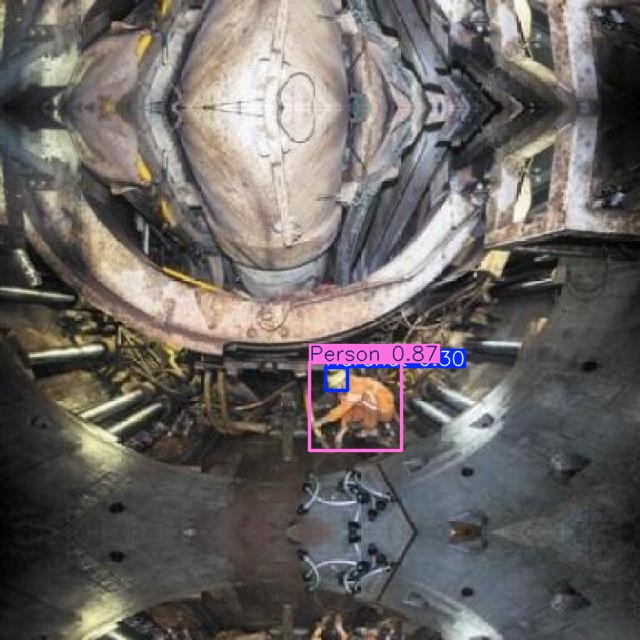

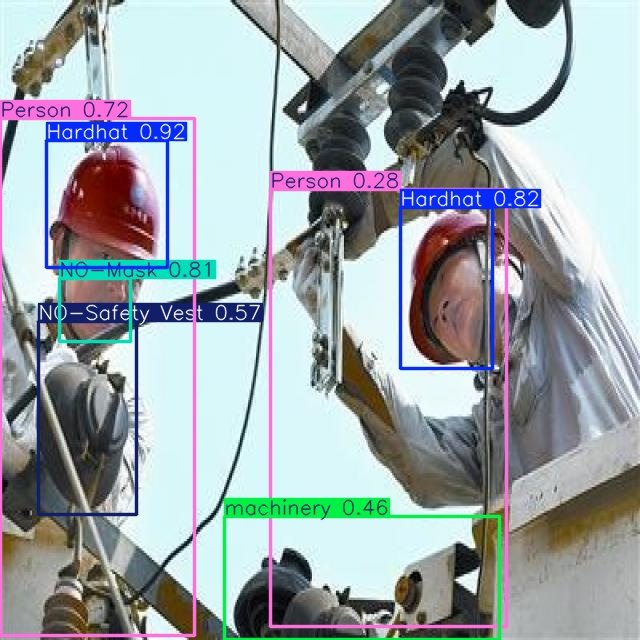

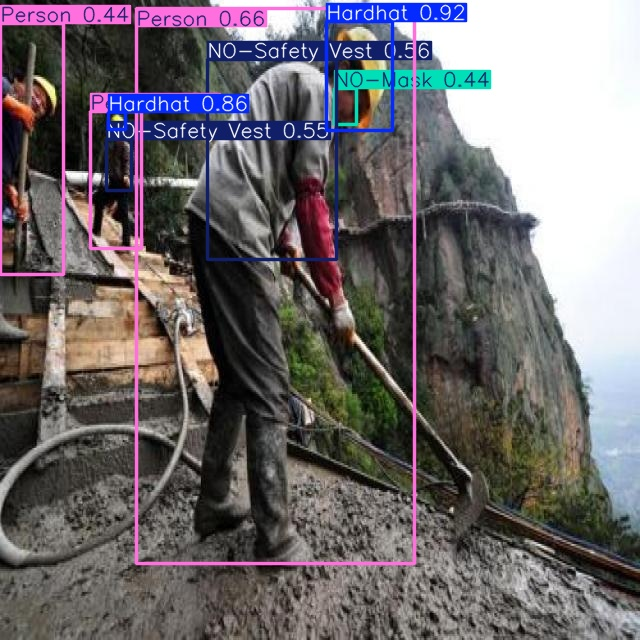

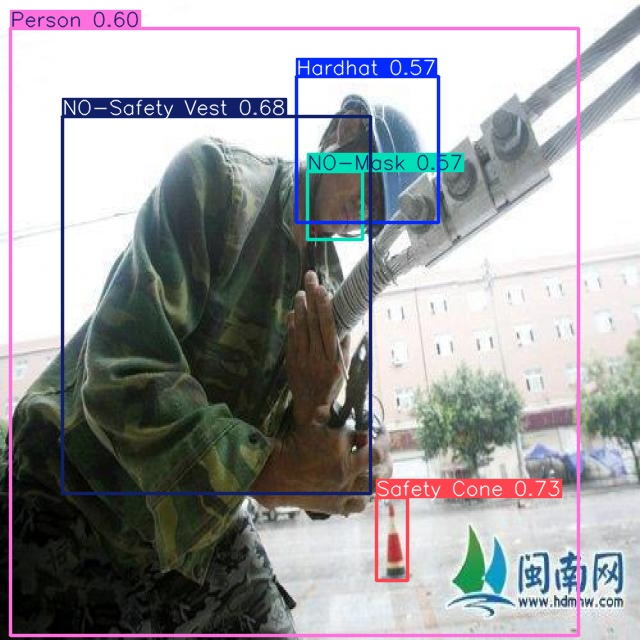

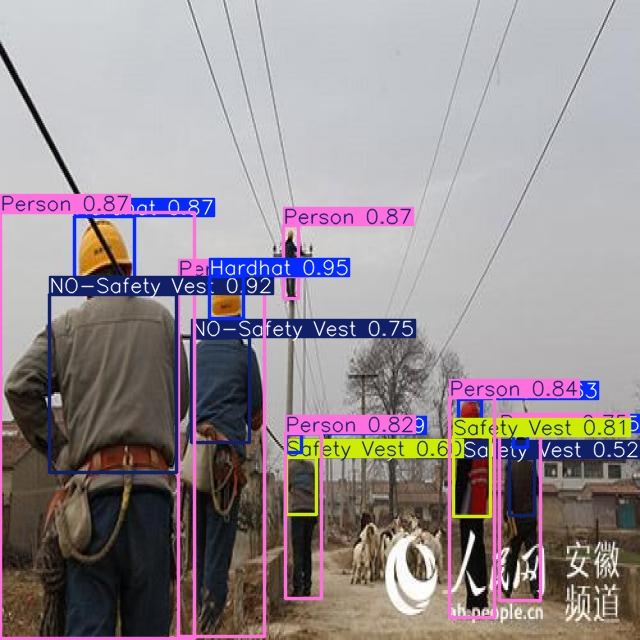

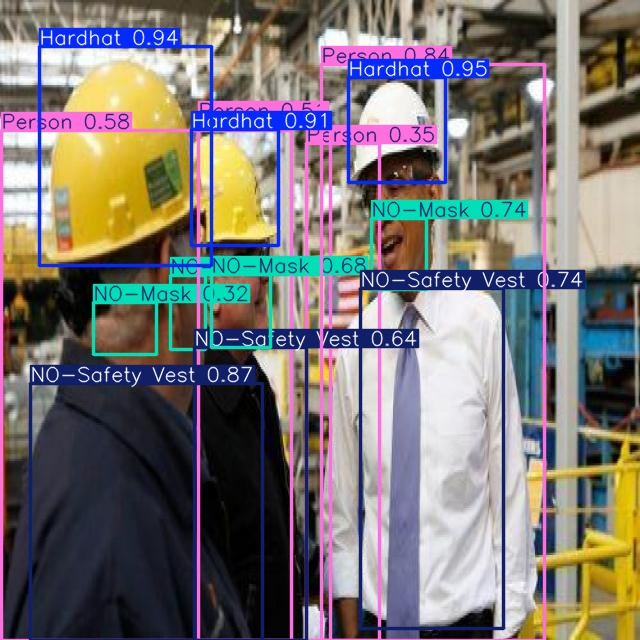


Showing 6 of 82 prediction images.


In [24]:
# Display sample predictions (images with violations)
print("\nSample predictions with violations:")
print("=" * 60)

pred_dir = '/content/n8n_inference/predictions'
pred_images = sorted(glob.glob(os.path.join(pred_dir, '*.jpg')) +
                     glob.glob(os.path.join(pred_dir, '*.png')))

# Show up to 6 prediction images
shown = 0
for img_path in pred_images[:6]:
    display(Image(filename=img_path, width=600))
    print()
    shown += 1

print(f"Showing {shown} of {len(pred_images)} prediction images.")

---
## 5. Send Results to n8n Safety Alert Pipeline

Package the detection results into a JSON payload and send to the n8n webhook. The n8n workflow will:
1. Parse violation counts and calculate compliance rate
2. Generate an AI-powered safety analysis using GPT-4o-mini
3. Email a formatted safety report to the designated safety manager

### n8n Workflow Architecture
```
Webhook → Parse Violations → OpenAI Analysis → Email Alert
```

In [25]:
# Build the detection payload for n8n
detections_payload = []
for cls in CLASS_NAMES:
    count = class_counts.get(cls, 0)
    if count > 0:
        avg_conf = round(np.mean(class_confidences[cls]), 2)
        detections_payload.append({
            "class": cls,
            "count": count,
            "avg_confidence": str(avg_conf)
        })

# Calculate compliance metrics
total_ppe_checks = sum(class_counts.get(c, 0) for c in VIOLATION_CLASSES + PPE_CLASSES)
total_compliant = sum(class_counts.get(c, 0) for c in PPE_CLASSES)
compliance_rate = round((total_compliant / total_ppe_checks * 100), 1) if total_ppe_checks > 0 else 0

payload = {
    "timestamp": datetime.now().isoformat(),
    "total_images": len(test_images),
    "detections": detections_payload
}

print("Payload to send to n8n:")
print(json.dumps(payload, indent=2))
print(f"\nCompliance rate: {compliance_rate}%")
print(f"Total violations: {total_violations}")

Payload to send to n8n:
{
  "timestamp": "2026-02-23T08:29:21.015067",
  "total_images": 82,
  "detections": [
    {
      "class": "Hardhat",
      "count": 95,
      "avg_confidence": "0.76"
    },
    {
      "class": "Mask",
      "count": 21,
      "avg_confidence": "0.85"
    },
    {
      "class": "NO-Hardhat",
      "count": 31,
      "avg_confidence": "0.66"
    },
    {
      "class": "NO-Mask",
      "count": 58,
      "avg_confidence": "0.54"
    },
    {
      "class": "NO-Safety Vest",
      "count": 75,
      "avg_confidence": "0.63"
    },
    {
      "class": "Person",
      "count": 150,
      "avg_confidence": "0.69"
    },
    {
      "class": "Safety Cone",
      "count": 60,
      "avg_confidence": "0.55"
    },
    {
      "class": "Safety Vest",
      "count": 58,
      "avg_confidence": "0.75"
    },
    {
      "class": "machinery",
      "count": 48,
      "avg_confidence": "0.68"
    },
    {
      "class": "vehicle",
      "count": 28,
      "avg_confidenc

In [26]:
# Send to n8n webhook
print("Sending detection results to n8n Safety Alert Pipeline...")
print(f"Webhook URL: {N8N_WEBHOOK_URL}")
print()

try:
    response = requests.post(
        N8N_WEBHOOK_URL,
        json=payload,
        headers={'Content-Type': 'application/json'},
        timeout=60
    )

    if response.status_code == 200:
        print("✅ SUCCESS — Safety alert pipeline triggered!")
        print(f"   Response status: {response.status_code}")
        print(f"   The n8n workflow will now:")
        print(f"   1. Parse {total_violations} violations across {len(images_with_violations)} images")
        print(f"   2. Generate AI safety analysis via GPT-4o-mini")
        print(f"   3. Email formatted report to safety manager")
        print(f"\n   Check your inbox for the safety alert email.")
    else:
        print(f"⚠️ Webhook returned status {response.status_code}")
        print(f"   Response: {response.text[:500]}")

except requests.exceptions.Timeout:
    print("⏳ Request timed out — the workflow may still be processing.")
    print("   Check your n8n dashboard and email inbox.")
except requests.exceptions.ConnectionError:
    print("❌ Could not connect to n8n webhook.")
    print("   Verify the workflow is active and the URL is correct.")
except Exception as e:
    print(f"❌ Error: {e}")

Sending detection results to n8n Safety Alert Pipeline...
Webhook URL: https://kaiiser.app.n8n.cloud/webhook/ppe-alert

✅ SUCCESS — Safety alert pipeline triggered!
   Response status: 200
   The n8n workflow will now:
   1. Parse 164 violations across 46 images
   2. Generate AI safety analysis via GPT-4o-mini
   3. Email formatted report to safety manager

   Check your inbox for the safety alert email.


---
## 6. Pipeline Summary

This notebook demonstrates an end-to-end deployment concept for construction site safety monitoring.

In [27]:
# Final summary
print("=" * 60)
print("M4U3 — AUTOMATED SAFETY ALERT PIPELINE SUMMARY")
print("=" * 60)
print()
print("DETECTION RESULTS")
print(f"  Images analyzed:        {len(test_images)}")
print(f"  Total detections:       {total_detections}")
print(f"  PPE violations found:   {total_violations}")
print(f"  Compliance rate:        {compliance_rate}%")
print(f"  Images with violations: {len(images_with_violations)}")
print()
print("VIOLATION BREAKDOWN")
for v_cls in VIOLATION_CLASSES:
    v_count = class_counts.get(v_cls, 0)
    v_conf = round(np.mean(class_confidences[v_cls]), 2) if v_cls in class_confidences else 0
    print(f"  {v_cls:<20} {v_count:>4} detections  (avg conf: {v_conf})")
print()
print("AUTOMATION PIPELINE")
print("  ✅ YOLOv8 inference completed")
print("  ✅ Results sent to n8n webhook")
print("  ✅ AI analysis generated (GPT-4o-mini)")
print("  ✅ Safety alert email dispatched")
print()
print("TECHNOLOGY STACK")
print("  Model:      YOLOv8n (Ultralytics)")
print("  Automation: n8n workflow engine")
print("  AI Report:  OpenAI GPT-4o-mini")
print("  Delivery:   SMTP email alert")
print("  Runtime:    Google Colab (T4 GPU)")
print()
print("This pipeline transforms a trained detection model into")
print("a production-ready safety monitoring system — bridging")
print("the gap between academic CV projects and real AECO deployment.")

M4U3 — AUTOMATED SAFETY ALERT PIPELINE SUMMARY

DETECTION RESULTS
  Images analyzed:        82
  Total detections:       624
  PPE violations found:   164
  Compliance rate:        51.5%
  Images with violations: 46

VIOLATION BREAKDOWN
  NO-Hardhat             31 detections  (avg conf: 0.66)
  NO-Mask                58 detections  (avg conf: 0.54)
  NO-Safety Vest         75 detections  (avg conf: 0.63)

AUTOMATION PIPELINE
  ✅ YOLOv8 inference completed
  ✅ Results sent to n8n webhook
  ✅ AI analysis generated (GPT-4o-mini)
  ✅ Safety alert email dispatched

TECHNOLOGY STACK
  Model:      YOLOv8n (Ultralytics)
  Automation: n8n workflow engine
  AI Report:  OpenAI GPT-4o-mini
  Delivery:   SMTP email alert
  Runtime:    Google Colab (T4 GPU)

This pipeline transforms a trained detection model into
a production-ready safety monitoring system — bridging
the gap between academic CV projects and real AECO deployment.
